#### Reference Hamiltonian

#### Import

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
from src.interaction_utils import EffectiveInteractionOptimizer
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import qutip as qt
from src.utils import computational_basis
from qutip import fidelity
from NSMFermions.hamiltonian_utils import FermiHubbardHamiltonian
from NSMFermions.nuclear_physics_utils import (
    get_twobody_nuclearshell_model,
    SingleParticleState,
)
import numpy as np
import torch
from typing import Dict
import scipy
from NSMFermions.qml_models import AdaptVQEFermiHubbard
from NSMFermions.qml_utils.train import Fit
from NSMFermions.qml_utils.utils import configuration
from scipy.sparse.linalg import eigsh, expm_multiply
from tqdm import trange
import matplotlib.pyplot as plt
from NSMFermions.utils_quasiparticle_approximation import (
    QuasiParticlesConverter,
    HardcoreBosonsBasis,
    QuasiParticlesConverterOnlynnpp,
)
from src.utils import generate_particleconservation_basis, array_to_qutip

/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


##### Parameters

In [8]:
data_onebody = np.load("data/matrix_elements_h_eff_2body/one_body_nn_sd.npz")
keys = data_onebody["keys"]
values = data_onebody["values"]
logical_qubits = 6

g_onebody = {}
diagonal_elements = np.zeros(logical_qubits)
g_matrix = np.zeros((logical_qubits, logical_qubits))
for a, key in enumerate(keys):
    i, j = key
    g_onebody[(i, j)] = values[a]
    if i != j:
        g_matrix[i, j] = values[a]
    if i == j:
        diagonal_elements[i] = values[a]

data_twobody = np.load("data/matrix_elements_h_eff_2body/twobody_nn_sd.npz")
keys = data_twobody["keys"]
values = data_twobody["values"]
g_twobody = {}
for a, key in enumerate(keys):
    i, j, k, l = key
    g_twobody[(i, j)] = values[a]
    print(i, j, k, l, values[a])
    if i != k and j != l:
        print(i, j, k, l)
        print(values[a])

# get the computational basis of the space
basis = computational_basis(logical_qubits)

0 1 0 1 -1.9616000000000007
0 2 0 2 -1.394600000000004
0 3 0 3 0.02873333333332795
0 4 0 4 -2.203928571428574
0 5 0 5 0.058295238095237956
1 2 1 2 -2.3017999999999965
1 3 1 3 0.0287333333333315
1 4 1 4 -0.8465942857142865
1 5 1 5 -1.2990390476190479
2 3 2 3 0.028733333333335054
2 4 2 4 -0.16792714285714272
2 5 2 5 -1.9777061904761917
3 4 3 4 0.015199999999999214
3 5 3 5 0.015199999999999214
4 5 4 5 -0.3896000000000015


In [9]:
hamiltonian_xy = 0.0
for i in range(logical_qubits):
    for j in range(i + 1, logical_qubits):
        hamiltonian_xy += SpinOperator(
            [("x", i, "x", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=logical_qubits,
            verbose=1,
        ).qutip_op
        hamiltonian_xy += SpinOperator(
            [("y", i, "y", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=logical_qubits,
            verbose=1,
        ).qutip_op
hamiltonian_z = 0.0
for i in range(logical_qubits):
    for j in range(i + 1, logical_qubits):
        hamiltonian_z += SpinOperator(
            [("qz", i, "qz", j)],
            coupling=[g_twobody[(i, j)]],
            size=logical_qubits,
            verbose=1,
        ).qutip_op

for i in range(logical_qubits):
    hamiltonian_z += SpinOperator(
        [("qz", i)], coupling=[diagonal_elements[i]], size=logical_qubits, verbose=1
    ).qutip_op

nsm_quasiparticle_hamiltonian = hamiltonian_z + hamiltonian_xy

In [10]:
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

print(eigenvalues_nsm)

[-42.71298534 -42.12274301 -41.3464     -40.18317535 -34.67433578
 -34.64777143 -33.43743989 -32.67421028 -29.79011229 -29.2564119
 -28.53176656 -28.41848438 -27.57197083 -27.35991208 -26.73932477
 -26.59414081 -25.98977465 -25.63385455 -25.3014     -25.10101513
 -23.42493918 -21.9654357  -20.89683668 -20.52242071 -19.67274996
 -19.28303066 -19.23514473 -19.21059676 -18.26654306 -17.95296014
 -17.88544834 -17.31381824 -17.26410663 -16.81194491 -16.50726894
 -15.9140891  -15.85882103 -14.75666784 -14.25484575 -13.26065145
 -13.21695938 -12.63396231 -12.54362933 -11.93178825 -11.78332373
  -9.40487689  -8.9655495   -8.37403332  -8.0583      -7.33926256
  -7.06474067  -6.85550939  -5.90728335  -5.44478182  -4.71386903
  -4.52953339  -4.44391355  -3.76845229  -3.22456721  -0.84349427
   0.           3.07695081   4.2394495    6.87857879]


In [13]:
import numpy as np
from src.utils import computational_basis
import qutip as qt

# or just set n_qubits directly if you know it

N_op = sum(
    SpinOperator([("qz", i)], coupling=[1], size=logical_qubits).qutip_op
    for i in range(logical_qubits)
)
print(N_op.shape)

# shape (2**logical_qubits, logical_qubits)

# --- get all eigenstates ---
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

# Get all eigenstates
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

# Filter by <psi|N|psi> == 1
N_target = 2
sector_indices = [
    i
    for i, psi in enumerate(eigenstates_nsm)
    if abs(qt.expect(N_op, psi) - N_target) < 1e-6
]

eigenvalues_N2 = eigenvalues_nsm[sector_indices]
eigenstates_N2 = [eigenstates_nsm[i] for i in sector_indices]

# Lowest energy state in the N=2 sector
idx = sector_indices[np.argmin(eigenvalues_nsm[sector_indices])]
ground_state_N2 = eigenstates_nsm[idx]
ground_eigenvalue_N2 = eigenvalues_nsm[idx]

print("Ground state energy in N=2 sector:", ground_eigenvalue_N2)
print("Ground state in N=2 sector (in computational basis):")

(64, 64)
Ground state energy in N=2 sector: -23.424939176438862
Ground state in N=2 sector (in computational basis):



   Bitstring    |amp|^2    Re(amp)    Im(amp)
----------------------------------------------
      000011    0.00103   -0.03207    0.00000
      000101    0.00505   -0.07109    0.00000
      000110    0.00506    0.07116    0.00000
      001001    0.00930   -0.09644    0.00000
      001010    0.01384    0.11765    0.00000
      001100    0.06162    0.24824    0.00000
      010001    0.01092    0.10450    0.00000
      010010    0.01209   -0.10995    0.00000
      010100    0.06138   -0.24775    0.00000
      011000    0.24072   -0.49063    0.00000
      100001    0.01444   -0.12018    0.00000
      100010    0.00882    0.09394    0.00000
      100100    0.06192    0.24883    0.00000
      101000    0.24912    0.49912    0.00000
      110000    0.24468   -0.49465    0.00000


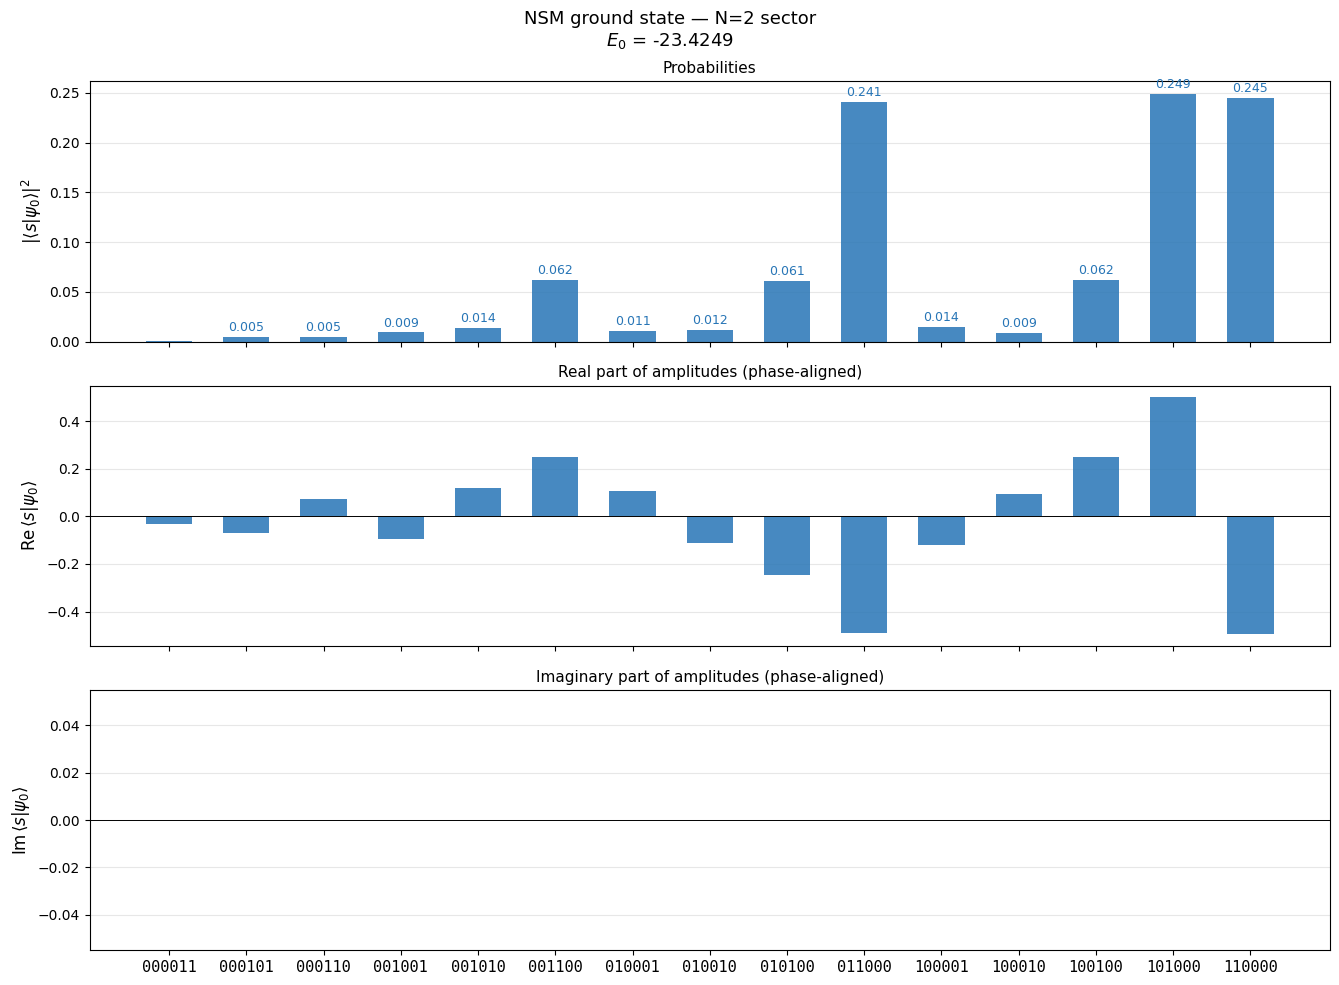

In [14]:
import matplotlib.pyplot as plt

# ── Amplitudes and probabilities of the NSM N=1 ground state ─────────────────

amps = ground_state_N2.full().flatten()  # complex amplitudes

# Phase-align: rotate so largest component is real+positive
idx_max = np.argmax(np.abs(amps))
amps_aligned = amps * np.exp(-1j * np.angle(amps[idx_max]))

probs = np.abs(amps_aligned) ** 2
re = amps_aligned.real
im = amps_aligned.imag

# Keep only N=2 sector bitstrings for plotting
basis_labels = ["".join(map(str, row)) for row in computational_basis(logical_qubits)]
n2_mask = np.array([sum(int(b) for b in lbl) == 2 for lbl in basis_labels])
labels_n2 = [l for l, m in zip(basis_labels, n2_mask) if m]

probs_n2 = probs[n2_mask]
re_n2 = re[n2_mask]
im_n2 = im[n2_mask]

# Print table
print(f"\n{'Bitstring':>12}  {'|amp|^2':>9}  {'Re(amp)':>9}  {'Im(amp)':>9}")
print("-" * 46)
for lbl, p, r, i_ in zip(labels_n2, probs_n2, re_n2, im_n2):
    print(f"{lbl:>12}  {p:>9.5f}  {r:>9.5f}  {i_:>9.5f}")

# ── Three-panel plot ──────────────────────────────────────────────────────────
CLR = "#2775b6"
x = np.arange(len(labels_n2))
width = 0.6

fig, axes = plt.subplots(3, 1, figsize=(max(6, len(labels_n2) * 0.9), 10), sharex=True)
fig.suptitle(
    f"NSM ground state — N=2 sector\n" f"$E_0$ = {ground_eigenvalue_N2:.4f}",
    fontsize=13,
)

# Panel 1: probabilities
ax = axes[0]
bars = ax.bar(x, probs_n2, width, color=CLR, alpha=0.85)
ax.set_ylabel(r"$|\langle s|\psi_0\rangle|^2$", fontsize=12)
ax.set_title("Probabilities", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
for bar, v in zip(bars, probs_n2):
    if v > 0.005:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.003,
            f"{v:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color=CLR,
        )

# Panel 2: real parts
ax = axes[1]
bars = ax.bar(x, re_n2, width, color=CLR, alpha=0.85)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Re}\,\langle s|\psi_0\rangle$", fontsize=12)
ax.set_title("Real part of amplitudes (phase-aligned)", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# Panel 3: imaginary parts
ax = axes[2]
bars = ax.bar(x, im_n2, width, color=CLR, alpha=0.85)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Im}\,\langle s|\psi_0\rangle$", fontsize=12)
ax.set_title("Imaginary part of amplitudes (phase-aligned)", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(labels_n2, fontfamily="monospace", fontsize=11)

plt.tight_layout()
plt.savefig("nsm_gs_wavefunction.pdf", bbox_inches="tight")
plt.show()

#### Getting the freaking effective Interaction

Optimal drive parameters: [ 0.90513022 -1.02535362  0.96153052  0.79417758  1.10508836 -1.13502171]
Optimized effective interaction matrix:
 [[ 0.00000000e+00  2.38278548e-01 -4.64010327e-01  1.81947764e-01
   9.31196815e-01  4.25607481e-01]
 [ 2.38278548e-01  0.00000000e+00  1.26008803e-01 -8.64690291e-02
  -5.12897701e-04  2.35762769e-01]
 [-4.64010327e-01  1.26008803e-01  0.00000000e+00  1.37155908e-01
  -3.27870146e-01 -7.07116593e-01]
 [ 1.81947764e-01 -8.64690291e-02  1.37155908e-01  0.00000000e+00
  -1.59923015e-01  1.83695413e-01]
 [ 9.31196815e-01 -5.12897701e-04 -3.27870146e-01 -1.59923015e-01
   0.00000000e+00  3.53399276e-01]
 [ 4.25607481e-01  2.35762769e-01 -7.07116593e-01  1.83695413e-01
   3.53399276e-01  0.00000000e+00]]


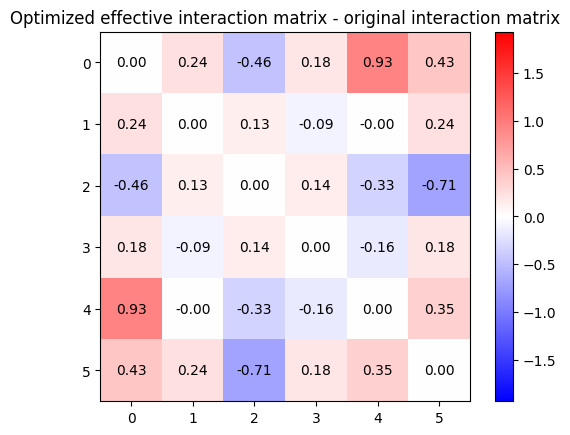

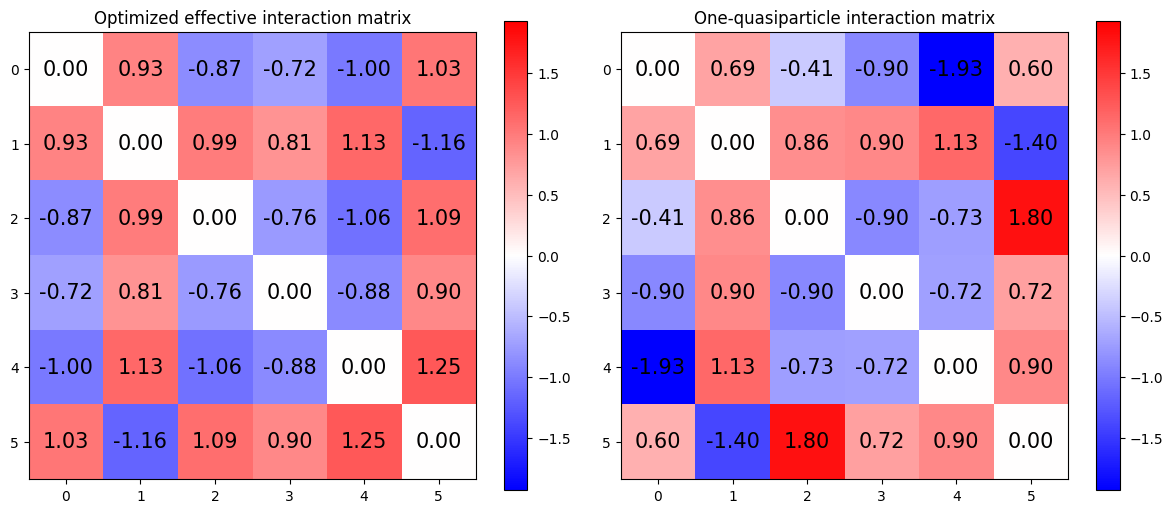

In [15]:
OptimalFieldBe6 = EffectiveInteractionOptimizer(
    nqubit=logical_qubits, n_restarts=100, scale=2.0, ftol=1e-15, gtol=1e-10
)

d_opt, result = OptimalFieldBe6.optimize_rank1(g_matrix)
print("Optimal drive parameters:", d_opt)
print(
    "Optimized effective interaction matrix:\n",
    OptimalFieldBe6.reconstructed(d_opt) - g_matrix,
)
plt.imshow(
    OptimalFieldBe6.reconstructed(d_opt) - g_matrix,
    cmap="bwr",
    vmin=-np.max(np.abs(g_matrix)),
    vmax=np.max(np.abs(g_matrix)),
)
for i in range(logical_qubits):
    for j in range(logical_qubits):
        plt.text(
            j,
            i,
            f"{OptimalFieldBe6.reconstructed(d_opt)[i,j]-g_matrix[i,j]:.2f}",
            ha="center",
            va="center",
            color="black",
        )
plt.colorbar()
plt.title("Optimized effective interaction matrix - original interaction matrix")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vmax = np.max(np.abs(g_matrix))
matrices = [OptimalFieldBe6.reconstructed(d_opt), g_matrix]
titles = [
    "Optimized effective interaction matrix",
    "One-quasiparticle interaction matrix",
]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.imshow(mat, cmap="bwr", vmin=-vmax, vmax=vmax)
    for i in range(logical_qubits):
        for j in range(logical_qubits):
            ax.text(
                j,
                i,
                f"{mat[i,j]:.2f}",
                ha="center",
                va="center",
                color="black",
                fontsize=15,
            )
    plt.colorbar(im, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

#### D-WAVE Embedding and effective Hamiltonians

In [16]:
import minorminer
import dwave_networkx as dnx
import networkx as nx

# K4: fully connected, 4 nodes = 6 edges
K4 = nx.complete_graph(6)
print("Problem edges:", list(K4.edges()))

# Hardware graph
hardware = dnx.pegasus_graph(16)

import minorminer

embedding = minorminer.find_embedding(K4, hardware)


# Manual verification
def check_embedding(embedding, problem_graph, hardware_graph):
    # Check 1: all chains connected in hardware
    for node, chain in embedding.items():
        subgraph = hardware_graph.subgraph(chain)
        if not nx.is_connected(subgraph):
            print(f"✗ q{node}: chain {chain} is NOT connected in hardware")
            return False

    # Check 2: every problem edge has a coupler between chains
    for u, v in problem_graph.edges():
        chain_u = set(embedding[u])
        chain_v = set(embedding[v])
        has_coupler = any(
            hardware_graph.has_edge(a, b) for a in chain_u for b in chain_v
        )
        if not has_coupler:
            print(
                f"✗ edge ({u},{v}): no coupler between chains {chain_u} and {chain_v}"
            )
            return False

    print("✓ Valid embedding")
    print(f"  Chain lengths: { {f'q{k}': len(v) for k,v in embedding.items()} }")
    return True


check_embedding(embedding, K4, hardware)

Problem edges: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 2), (1, 3), (1, 4), (1, 5), (2, 3), (2, 4), (2, 5), (3, 4), (3, 5), (4, 5)]
✓ Valid embedding
  Chain lengths: {'q0': 2, 'q1': 2, 'q2': 1, 'q3': 1, 'q4': 1, 'q5': 1}


True

/tmp/ipykernel_3001/1441097168.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


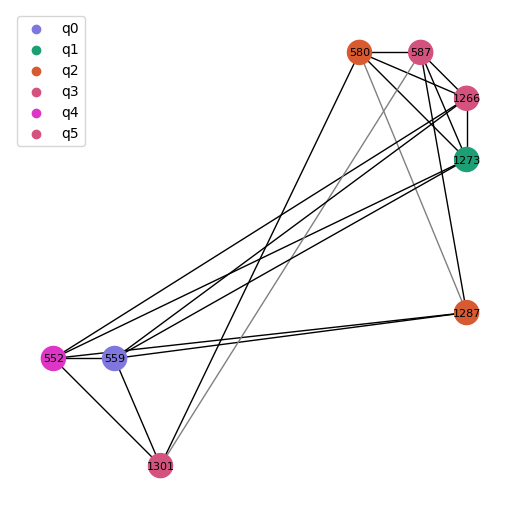

In [17]:
import matplotlib.pyplot as plt
import dwave_networkx as dnx
import minorminer
import networkx as nx

K4 = nx.complete_graph(6)
hardware = dnx.pegasus_graph(8)
embedding = minorminer.find_embedding(K4, hardware)

# Extract only the hardware nodes/edges used
used_nodes = [node for chain in embedding.values() for node in chain]
used_edges = []
for u, v in K4.edges():
    for a in embedding[u]:
        for b in embedding[v]:
            if hardware.has_edge(a, b):
                used_edges.append((a, b))

# Color by logical qubit
colors = [
    "#7F77DD",
    "#1D9E75",
    "#D85A30",
    "#D4537E",
    "#DD36C7",
    "#D4537E",
]  # purple, teal, coral, pink
node_colors = {}
for i, chain in embedding.items():
    for node in chain:
        node_colors[node] = colors[i]

subgraph = hardware.subgraph(used_nodes).copy()
for u, v in used_edges:
    if not subgraph.has_edge(u, v):
        subgraph.add_edge(u, v)

pos = dnx.pegasus_layout(subgraph)

plt.figure(figsize=(5, 5))
nx.draw(
    subgraph,
    pos,
    node_color=[node_colors[n] for n in subgraph.nodes()],
    edge_color=[
        "gray" if (u, v) not in used_edges and (v, u) not in used_edges else "black"
        for u, v in subgraph.edges()
    ],
    node_size=300,
    with_labels=True,
    font_size=8,
)
plt.legend(handles=[plt.scatter([], [], c=colors[i], label=f"q{i}") for i in range(6)])
plt.tight_layout()
plt.savefig("embedding.png", dpi=150)
plt.show()

In [18]:
print(used_nodes)
print(used_edges)

# build index map: physical qubit → local index 0..7
phys_to_idx = {phys: idx for idx, phys in enumerate(used_nodes)}

print("=== Physical → Local index ===")
for phys, idx in phys_to_idx.items():
    print(f"  {phys} → {idx}")

print("\n=== Chains (local indices) ===")
mapping = []
for logical, chain in embedding.items():
    local_chain = [phys_to_idx[p] for p in chain]
    mapping.append(local_chain)
    print(f"  q{logical} → {local_chain}")

print("\n=== Edges (local indices) ===")
local_edges = [(phys_to_idx[u], phys_to_idx[v]) for u, v in used_edges]
print(local_edges)

[559, 1273, 1287, 580, 1301, 587, 552, 1266]
[(559, 1273), (559, 1287), (559, 1301), (559, 552), (559, 1266), (1273, 580), (1273, 587), (1273, 552), (1273, 1266), (1287, 587), (580, 1301), (580, 587), (1287, 552), (580, 1266), (1301, 552), (587, 1266), (552, 1266)]
=== Physical → Local index ===
  559 → 0
  1273 → 1
  1287 → 2
  580 → 3
  1301 → 4
  587 → 5
  552 → 6
  1266 → 7

=== Chains (local indices) ===
  q0 → [0]
  q1 → [1]
  q2 → [2, 3]
  q3 → [4, 5]
  q4 → [6]
  q5 → [7]

=== Edges (local indices) ===
[(0, 1), (0, 2), (0, 4), (0, 6), (0, 7), (1, 3), (1, 5), (1, 6), (1, 7), (2, 5), (3, 4), (3, 5), (2, 6), (3, 7), (4, 6), (5, 7), (6, 7)]


Encoding

In [19]:
# chains dict: already comes from embedding + phys_to_idx
chains = {
    logical: [phys_to_idx[p] for p in chain] for logical, chain in embedding.items()
}

# intra_edges: pairs within the same chain that are connected in hardware
intra_edges = []
for logical, chain in chains.items():
    local_chain = [phys_to_idx[p] for p in embedding[logical]]
    for k in range(len(local_chain) - 1):
        intra_edges.append((local_chain[k], local_chain[k + 1]))

# inter_edges: all local_edges minus intra_edges
intra_set = set(map(frozenset, intra_edges))
inter_edges = [(u, v) for u, v in local_edges if frozenset((u, v)) not in intra_set]

print("Chains:", chains)
print("Intra edges:", intra_edges)
print("Inter edges:", inter_edges)
print("Representatives:", {l: chain[0] for l, chain in chains.items()})

Chains: {0: [0], 1: [1], 2: [2, 3], 3: [4, 5], 4: [6], 5: [7]}
Intra edges: [(2, 3), (4, 5)]
Inter edges: [(0, 1), (0, 2), (0, 4), (0, 6), (0, 7), (1, 3), (1, 5), (1, 6), (1, 7), (2, 5), (3, 4), (3, 5), (2, 6), (3, 7), (4, 6), (5, 7), (6, 7)]
Representatives: {0: 0, 1: 1, 2: 2, 3: 4, 4: 6, 5: 7}


In [20]:
# physical qubit -> logical qubit lookup
phys_to_logical = {}
for logical, chain in chains.items():
    for p in chain:
        phys_to_logical[p] = logical

In [25]:
# for each logical pair, find the physical coupler
logical_pair_to_physical_coupler = {}
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]
    if lu == lv:
        continue
    pair = frozenset((lu, lv))
    if pair not in logical_pair_to_physical_coupler:
        logical_pair_to_physical_coupler[pair] = (u, v)

print("=== Logical pair → physical coupler ===")
for pair, (u, v) in logical_pair_to_physical_coupler.items():
    lu, lv = tuple(pair)
    print(f"  q{lu}-q{lv}: physical ({u},{v})")

=== Logical pair → physical coupler ===
  q0-q1: physical (0,1)
  q0-q2: physical (0,2)
  q0-q3: physical (0,4)
  q0-q4: physical (0,6)
  q0-q5: physical (0,7)
  q1-q2: physical (1,3)
  q1-q3: physical (1,5)
  q1-q4: physical (1,6)
  q1-q5: physical (1,7)
  q2-q3: physical (2,5)
  q2-q4: physical (2,6)
  q2-q5: physical (3,7)
  q3-q4: physical (4,6)
  q3-q5: physical (5,7)
  q4-q5: physical (6,7)


In [221]:
import qutip as qt
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import numpy as np
from collections import defaultdict

gamma = 100
J_F = 5 * gamma
n_physical = 8
N_tot = 2

identity = qt.tensor([qt.qeye(2)] * n_physical)

# build a lookup: logical qubit -> representative physical qubit
representatives = {logical: chain[0] for logical, chain in chains.items()}

# build a lookup: physical qubit -> logical qubit
phys_to_logical = {}
for logical, chain in chains.items():
    for p in chain:
        phys_to_logical[p] = logical

# recheck: with gamma=20, N_tot=1
# gamma*(1 - 2*N_tot) = 20*(1-2) = -20  ← this is correct
# but ZZ coupling 2*gamma = 40 per pair

# the problem is that for chains, BOTH physical qubits are being
# set in the one-hot state. The constraint must act on representatives ONLY.

# verify representatives
print("Representatives:", representatives)
# should be: {0:0, 1:1, 2:2, 3:4, 4:6, 5:7}
# q2 representative is 2 (not both 2 and 3)
# q3 representative is 4 (not both 4 and 5)

# rebuild hamiltonian_zz using ONLY representatives
hamiltonian_zz = 0.0
added_pairs = set()
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]
    print(lu, lv, u, v)
    if lu == lv:
        continue
    pair = frozenset((lu, lv))
    if pair in added_pairs:
        continue
    added_pairs.add(pair)
    # use the actual hardware coupler (u,v), not the representatives
    print(f"  logical (q{lu},q{lv}): physical coupler ({u},{v})")
    hamiltonian_zz += SpinOperator(
        [("qz", u, "qz", v)],
        coupling=[2 * gamma + g_twobody[(lu, lv)] / gamma],
        size=n_physical,
        verbose=0,
    ).qutip_op
    print(
        f"Added NN coupling for logical pair (q{lu}, q{lv}) with physical coupler ({u},{v})"
    )
print(f"ZZ pairs added: {len(added_pairs)}")


# track which physical qubits carry ZZ for each logical qubit
logical_to_physical_in_zz = defaultdict(set)
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]
    if lu == lv:
        continue
    pair = frozenset((lu, lv))
    if pair not in added_pairs:
        continue
    logical_to_physical_in_zz[lu].add(u)
    logical_to_physical_in_zz[lv].add(v)


hamiltonian_z = 0.0
h_constraint = gamma * (1 - 2 * N_tot)
for logical in range(6):
    eps = diagonal_elements[logical] / (gamma)
    p = chains[logical][0]  # always the representative
    hamiltonian_z += SpinOperator(
        [("qz", p)], coupling=[h_constraint + eps], size=n_physical, verbose=0
    ).qutip_op
    print(f"Constraint on logical q{logical} -> physical qubit {p}")

# H_diagonal = 0.0
# for logical, chain in chains.items():
#     k = len(chain)
#     print(f"Logical qubit {logical} has chain {chain} with length {k}")
#     eps = diagonal_elements[logical] / (gamma * k)
#     for phys in chain:
#         H_diagonal += SpinOperator(
#             [("qz", phys)], coupling=[eps], size=n_physical
#         ).qutip_op


identity = qt.tensor([qt.qeye(2)] * n_physical)
H_constraint = hamiltonian_zz + hamiltonian_z


H_ferro = 0.0
for a, b in intra_edges:
    H_ferro += SpinOperator(
        [("z", a, "z", b)], coupling=[-J_F], size=n_physical, verbose=0
    ).qutip_op
    print(f"Added ferromagnetic coupling for intra-edge ({a},{b})")

longitudinal_hamiltonian = (
    H_constraint
    + H_ferro
    # + H_diagonal
    + gamma * identity * N_tot**2
    + identity * J_F * 2
)

# check spectrum
evals = np.sort(np.real(longitudinal_hamiltonian.eigenenergies()))
print("Spectrum (first 8):", evals[:8])
print("Ground state degeneracy:", np.sum(np.isclose(evals, evals[0])))

Representatives: {0: 0, 1: 1, 2: 2, 3: 4, 4: 6, 5: 7}
0 1 0 1
  logical (q0,q1): physical coupler (0,1)
Added NN coupling for logical pair (q0, q1) with physical coupler (0,1)
0 2 0 2
  logical (q0,q2): physical coupler (0,2)
Added NN coupling for logical pair (q0, q2) with physical coupler (0,2)
0 3 0 4
  logical (q0,q3): physical coupler (0,4)
Added NN coupling for logical pair (q0, q3) with physical coupler (0,4)
0 4 0 6
  logical (q0,q4): physical coupler (0,6)
Added NN coupling for logical pair (q0, q4) with physical coupler (0,6)
0 5 0 7
  logical (q0,q5): physical coupler (0,7)
Added NN coupling for logical pair (q0, q5) with physical coupler (0,7)
1 2 1 3
  logical (q1,q2): physical coupler (1,3)
Added NN coupling for logical pair (q1, q2) with physical coupler (1,3)
1 3 1 5
  logical (q1,q3): physical coupler (1,5)
Added NN coupling for logical pair (q1, q3) with physical coupler (1,5)
1 4 1 6
  logical (q1,q4): physical coupler (1,6)
Added NN coupling for logical pair (q1, q4

In [222]:
# get eigenvalues and eigenstates
evals, evecs = longitudinal_hamiltonian.eigenstates()

print("=== Lowest energy states ===")
for k in range(20):
    energy = evals[k]
    state = evecs[k]

    # get probabilities over computational basis
    probs = np.abs(state.full().flatten()) ** 2
    dominant_idx = np.argmax(probs)

    # convert to bitstring (8 qubits)
    bitstring = format(dominant_idx, f"0{n_physical}b")

    print(
        f"  E[{k}] = {energy:.4f} | bitstring: {bitstring} | prob: {probs[dominant_idx]:.4f}"
    )

=== Lowest energy states ===
  E[0] = -0.2031 | bitstring: 01110000 | prob: 1.0000
  E[1] = -0.2014 | bitstring: 11000000 | prob: 1.0000
  E[2] = -0.1985 | bitstring: 10110000 | prob: 1.0000
  E[3] = -0.1739 | bitstring: 10001100 | prob: 1.0000
  E[4] = -0.1722 | bitstring: 00111100 | prob: 1.0000
  E[5] = -0.1694 | bitstring: 01001100 | prob: 1.0000
  E[6] = -0.0829 | bitstring: 10000010 | prob: 1.0000
  E[7] = -0.0790 | bitstring: 00110001 | prob: 1.0000
  E[8] = -0.0694 | bitstring: 01000001 | prob: 1.0000
  E[9] = -0.0648 | bitstring: 01000010 | prob: 1.0000
  E[10] = -0.0609 | bitstring: 00110010 | prob: 1.0000
  E[11] = -0.0603 | bitstring: 10000001 | prob: 1.0000
  E[12] = -0.0487 | bitstring: 00001101 | prob: 1.0000
  E[13] = -0.0487 | bitstring: 00001110 | prob: 1.0000
  E[14] = 0.0606 | bitstring: 00000011 | prob: 1.0000
  E[15] = 99.6702 | bitstring: 11110000 | prob: 1.0000
  E[16] = 99.7164 | bitstring: 01111100 | prob: 1.0000
  E[17] = 99.7181 | bitstring: 11001100 | prob:

In [223]:
print("\n=== Chain qubit used for each logical pair ===")
added_pairs2 = set()
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]
    if lu == lv:
        continue
    pair = frozenset((lu, lv))
    if pair in added_pairs2:
        continue
    added_pairs2.add(pair)
    ru, rv = representatives[lu], representatives[lv]
    flag = ""
    if u != ru or v != rv:
        flag = "  ← NON-REPRESENTATIVE"
    print(f"  logical (q{lu},q{lv}): physical ({u},{v}) | reps ({ru},{rv}){flag}")


=== Chain qubit used for each logical pair ===
  logical (q0,q1): physical (0,1) | reps (0,1)
  logical (q0,q2): physical (0,2) | reps (0,2)
  logical (q0,q3): physical (0,4) | reps (0,4)
  logical (q0,q4): physical (0,6) | reps (0,6)
  logical (q0,q5): physical (0,7) | reps (0,7)
  logical (q1,q2): physical (1,3) | reps (1,2)  ← NON-REPRESENTATIVE
  logical (q1,q3): physical (1,5) | reps (1,4)  ← NON-REPRESENTATIVE
  logical (q1,q4): physical (1,6) | reps (1,6)
  logical (q1,q5): physical (1,7) | reps (1,7)
  logical (q2,q3): physical (2,5) | reps (2,4)  ← NON-REPRESENTATIVE
  logical (q2,q4): physical (2,6) | reps (2,6)
  logical (q2,q5): physical (3,7) | reps (2,7)  ← NON-REPRESENTATIVE
  logical (q3,q4): physical (4,6) | reps (4,6)
  logical (q3,q5): physical (5,7) | reps (4,7)  ← NON-REPRESENTATIVE
  logical (q4,q5): physical (6,7) | reps (6,7)


In [224]:
# check each term independently
print("=== H_constraint diagonal ===")
diag_constraint = np.real(longitudinal_hamiltonian.full().diagonal())
idx_sorted = np.argsort(diag_constraint)
for k in idx_sorted[:6]:
    bitstring = format(k, f"0{n_physical}b")[::-1]
    n_particles = sum(int(b) for b in bitstring)
    print(f"  {bitstring} | N={n_particles} | E={diag_constraint[k]:.4f}")

print("\n=== H_ferro diagonal ===")
diag_ferro = np.real(H_ferro.full().diagonal())
idx_sorted = np.argsort(diag_ferro)
for k in idx_sorted[:6]:
    bitstring = format(k, f"0{n_physical}b")[::-1]
    print(f"  {bitstring} | E={diag_ferro[k]:.4f}")

print("\n=== H_total diagonal ===")
diag_total = np.real(longitudinal_hamiltonian.full().diagonal())
idx_sorted = np.argsort(diag_total)
for k in idx_sorted[:6]:
    bitstring = format(k, f"0{n_physical}b")[::-1]
    n_particles = sum(int(b) for b in bitstring)
    print(f"  {bitstring} | N={n_particles} | E={diag_total[k]:.4f}")

# also print current parameter values
print(f"\ngamma={gamma}, J_F={J_F}, N_tot={N_tot}")
print(f"chains: {chains}")
print(f"intra_edges: {intra_edges}")
print(f"representatives: {representatives}")

=== H_constraint diagonal ===
  00001110 | N=3 | E=-0.2031
  00000011 | N=2 | E=-0.2014
  00001101 | N=3 | E=-0.1985
  00110001 | N=3 | E=-0.1739
  00111100 | N=4 | E=-0.1722
  00110010 | N=3 | E=-0.1694

=== H_ferro diagonal ===
  00000000 | E=-1000.0000
  10000000 | E=-1000.0000
  01000000 | E=-1000.0000
  11000000 | E=-1000.0000
  00110000 | E=-1000.0000
  10110000 | E=-1000.0000

=== H_total diagonal ===
  00001110 | N=3 | E=-0.2031
  00000011 | N=2 | E=-0.2014
  00001101 | N=3 | E=-0.1985
  00110001 | N=3 | E=-0.1739
  00111100 | N=4 | E=-0.1722
  00110010 | N=3 | E=-0.1694

gamma=100, J_F=500, N_tot=2
chains: {0: [0], 1: [1], 2: [2, 3], 3: [4, 5], 4: [6], 5: [7]}
intra_edges: [(2, 3), (4, 5)]
representatives: {0: 0, 1: 1, 2: 2, 3: 4, 4: 6, 5: 7}


##### Adding the transverse field

In [225]:
d_phys = np.zeros(n_physical)
for logical, chain in chains.items():
    if len(chain) == 1:
        d_phys[chain[0]] = d_opt[logical] / np.sqrt(2)
    else:
        d_logical = d_opt[logical] / np.sqrt(2)
        magnitude = np.sqrt(np.abs(d_logical) * J_F)
        d_phys[chain[0]] = +magnitude
        d_phys[chain[1]] = -1 * np.sign(d_logical) * magnitude

# transverse field on physical qubits
transverse_hamiltonian = 0.0
for phys_idx in range(n_physical):
    transverse_hamiltonian += SpinOperator(
        [("x", phys_idx)], coupling=[d_phys[phys_idx]], size=n_physical, verbose=0
    ).qutip_op

Generalized formula

In [226]:
d_phys = np.zeros(n_physical)
for logical, chain in chains.items():
    k = len(chain)
    d_logical = d_opt[logical] / np.sqrt(2)
    magnitude = (np.abs(d_logical) ** (1 / k)) * ((J_F) ** ((k - 1) / k))
    for i, phys in enumerate(chain):
        if k == 1:
            d_phys[phys] = d_logical  # no perturbation, keep sign directly
        elif i < k - 1:
            d_phys[phys] = +magnitude
        else:
            d_phys[phys] = -np.sign(d_logical) * magnitude
# transverse field on physical qubits
transverse_hamiltonian = 0.0
for phys_idx in range(n_physical):
    transverse_hamiltonian += SpinOperator(
        [("x", phys_idx)], coupling=[d_phys[phys_idx]], size=n_physical, verbose=0
    ).qutip_op

In [227]:
# full hamiltonian with transverse field
H_total = H_constraint + H_ferro + transverse_hamiltonian  # + H_diagonal

# diagonalize
evals, evecs = H_total.eigenstates()
gs_emb = evecs[0].full().flatten()
print("=== Ground state analysis ===")
print(f"Ground state energy: {np.real(evals[0]):.6f}")
print(f"First excited energy: {np.real(evals[1]):.6f}")
print(f"Gap: {np.real(evals[1] - evals[0]):.6f}")

print("\n=== Ground state bitstring decomposition ===")
gs = evecs[0]
probs = np.abs(gs.full().flatten()) ** 2

# sort by probability
sorted_idx = np.argsort(probs)[::-1]

print(f"{'bitstring':>12}  {'prob':>8}  {'logical meaning'}")
print("-" * 50)
for idx in sorted_idx[:20]:  # top 10 components
    if probs[idx] < 1e-6:
        break
    bitstring = format(idx, f"0{n_physical}b")  # reverse for q0=LSB

    # identify which logical qubit is occupied
    occupied_physical = [i for i, b in enumerate(bitstring) if b == "1"]
    occupied_logical = []
    for phys in occupied_physical:
        for logical, chain in chains.items():
            if phys in chain:
                occupied_logical.append(f"q{logical}")

    print(f"  {bitstring}  {probs[idx]:>8.4f}  {occupied_logical}")

=== Ground state analysis ===
Ground state energy: -1401.530783
First excited energy: -1401.457326
Gap: 0.073458

=== Ground state bitstring decomposition ===
   bitstring      prob  logical meaning
--------------------------------------------------
  01110000    0.8736  ['q1', 'q2', 'q2']
  01000001    0.0278  ['q1', 'q5']
  11000000    0.0222  ['q0', 'q1']
  01001100    0.0168  ['q1', 'q3', 'q3']
  10110000    0.0159  ['q0', 'q2', 'q2']
  00110001    0.0152  ['q2', 'q2', 'q5']
  00111100    0.0134  ['q2', 'q2', 'q3', 'q3']
  01000010    0.0050  ['q1', 'q4']
  00110010    0.0040  ['q2', 'q2', 'q4']
  10001100    0.0014  ['q0', 'q3', 'q3']
  10000001    0.0008  ['q0', 'q5']
  00001101    0.0008  ['q3', 'q3', 'q5']
  01111000    0.0005  ['q1', 'q2', 'q2', 'q3']
  10000010    0.0005  ['q0', 'q4']
  01100000    0.0005  ['q1', 'q2']
  00001110    0.0003  ['q3', 'q3', 'q4']
  00000011    0.0003  ['q4', 'q5']
  01010000    0.0002  ['q1', 'q2']
  01110100    0.0001  ['q1', 'q2', 'q2', 'q3']
 

In [ ]:
def qutip_idx(occupied_qubits, n_qubits):
    """
    Given a list of occupied qubit indices and total number of qubits,
    return the index in the QuTiP state vector.
    QuTiP uses MSB convention: qubit 0 is the most significant bit.
    e.g. n=6, occupied=[0] -> bitstring 100000 -> index 32
         n=6, occupied=[5] -> bitstring 000001 -> index 1
         n=8, occupied=[2,3] -> bitstring 00110000 -> index 48
    """
    idx = 0
    for q in occupied_qubits:
        idx += 1 << (n_qubits - 1 - q)
    return idx


# === Full wavefunction comparison: amplitudes ===

# --- Exact amplitudes (phase-aligned to largest component) ---
gs_exact = ground_state_N2.full().flatten()
exact_amps = np.array(
    [gs_exact[qutip_idx([l], logical_qubits)] for l in range(logical_qubits)]
)

# phase-align exact to largest component
idx_max = np.argmax(np.abs(exact_amps))
exact_amps = exact_amps * np.exp(-1j * np.angle(exact_amps[idx_max]))

# --- Embedded amplitudes (projected onto logical one-hot states) ---
emb_amps = np.array(
    [gs_emb[qutip_idx(chains[l], n_physical)] for l in range(logical_qubits)]
)

# phase-align embedded to same reference (q_idx_max)
emb_amps = emb_amps * np.exp(-1j * np.angle(emb_amps[idx_max]))

# --- Print table ---
print(
    f"{'Logical':>8}  {'Re(exact)':>10}  {'Re(emb)':>10}  {'Im(exact)':>10}  {'Im(emb)':>10}  {'|exact|^2':>10}  {'|emb|^2':>10}"
)
print("-" * 75)
for l in range(logical_qubits):
    print(
        f"  q{l}  "
        f"{exact_amps[l].real:>10.5f}  {emb_amps[l].real:>10.5f}  "
        f"{exact_amps[l].imag:>10.5f}  {emb_amps[l].imag:>10.5f}  "
        f"{np.abs(exact_amps[l])**2:>10.5f}  {np.abs(emb_amps[l])**2:>10.5f}"
    )

# overall norm of projected embedded state
print(f"\nNorm of projected embedded wavefunction: {np.sum(np.abs(emb_amps)**2):.5f}")
print("(< 1 means weight lost to domain-wall / multi-particle states)")

# --- Plot ---

 Logical   Re(exact)     Re(emb)   Im(exact)     Im(emb)   |exact|^2     |emb|^2
---------------------------------------------------------------------------
  q0     0.00000    -0.00969     0.00000     0.00000     0.00000     0.00009
  q1     0.00000     0.01756     0.00000     0.00000     0.00000     0.00031
  q2     0.00000    -0.01176     0.00000     0.00000     0.00000     0.00014
  q3     0.00000    -0.00906     0.00000     0.00000     0.00000     0.00008
  q4     0.00000    -0.00403     0.00000     0.00000     0.00000     0.00002
  q5     0.00000     0.00541    -0.00000     0.00000     0.00000     0.00003

Norm of projected embedded wavefunction: 0.00067
(< 1 means weight lost to domain-wall / multi-particle states)


Fidelity (raw, includes norm loss): 0.792158
Norm of projected embedded state:   0.896093


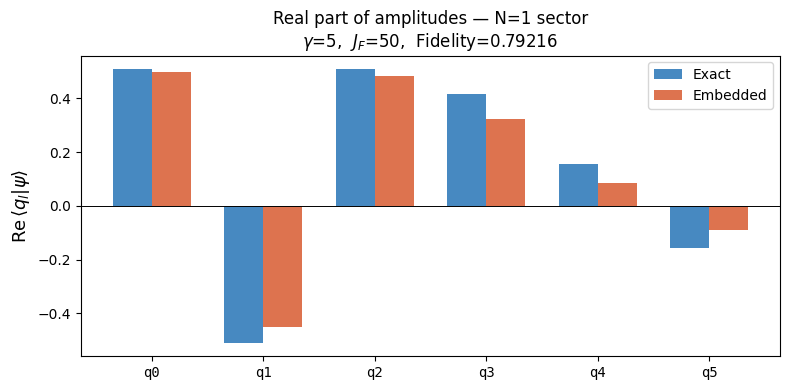

In [50]:
# === Real part only + fidelity (no prenormalization) ===

fidelity = np.abs(np.dot(np.conj(exact_amps), emb_amps)) ** 2
print(f"Fidelity (raw, includes norm loss): {fidelity:.6f}")
print(f"Norm of projected embedded state:   {np.sqrt(np.sum(np.abs(emb_amps)**2)):.6f}")

# --- Plot: real part only ---
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(logical_qubits)
w = 0.35
labels = [f"q{l}" for l in range(logical_qubits)]
CLR_E = "#2775b6"
CLR_M = "#d85a30"

ax.bar(x - w / 2, exact_amps.real, w, color=CLR_E, alpha=0.85, label="Exact")
ax.bar(x + w / 2, emb_amps.real, w, color=CLR_M, alpha=0.85, label="Embedded")
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Re}\,\langle q_l|\psi\rangle$", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontfamily="monospace")
ax.legend()
ax.set_title(
    f"Real part of amplitudes — N=1 sector\n"
    f"$\\gamma$={gamma},  $J_F$={J_F},  Fidelity={fidelity:.5f}",
    fontsize=12,
)
plt.tight_layout()
plt.savefig("wavefunction_real.pdf", bbox_inches="tight")
plt.show()

In [39]:
print(np.sum(np.abs(exact_amps) ** 2))  # should be ~1
print(np.sum(np.abs(emb_amps) ** 2))  # how much norm in one-hot sector
print(np.dot(np.conj(exact_amps), emb_amps))  # raw overlap before squaring

1.0
0.9986475598505458
(0.9990859306754665-2.4470547741497284e-16j)


In [40]:
for l, chain in chains.items():
    print(f"logical q{l}: chain {chain}, length {len(chain)}")

logical q0: chain [0, 1], length 2
logical q1: chain [2], length 1
logical q2: chain [3], length 1
logical q3: chain [4], length 1
logical q4: chain [5, 6], length 2
logical q5: chain [7], length 1


In [28]:
print("inter_edges:", inter_edges)
print("chains:", chains)
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]
    print(f"  edge ({u},{v}): logical ({lu},{lv})")

inter_edges: [(0, 2), (0, 3), (1, 4), (1, 5), (1, 7), (2, 3), (2, 4), (2, 5), (2, 7), (3, 4), (3, 5), (3, 7), (4, 6), (4, 7), (6, 7)]
chains: {0: [0, 1], 1: [2], 2: [3], 3: [4], 4: [5, 6], 5: [7]}
  edge (0,2): logical (0,1)
  edge (0,3): logical (0,2)
  edge (1,4): logical (0,3)
  edge (1,5): logical (0,4)
  edge (1,7): logical (0,5)
  edge (2,3): logical (1,2)
  edge (2,4): logical (1,3)
  edge (2,5): logical (1,4)
  edge (2,7): logical (1,5)
  edge (3,4): logical (2,3)
  edge (3,5): logical (2,4)
  edge (3,7): logical (2,5)
  edge (4,6): logical (3,4)
  edge (4,7): logical (3,5)
  edge (6,7): logical (4,5)
